In [1]:
import gpt as g
import sys, os
import numpy as np

from scipy.linalg import expm
import time
import matplotlib.pyplot as plt
from gpt.qcd.gauge.smear import local_stout  
from gpt.ad import reverse as rad
from gpt.qcd.gauge.smear.differentiable import dft_diffeomorphism
import time
import random

SharedMemoryNone: SharedMemoryAllocate 1073741824 GPU implementation 
0SharedMemoryNone:  SharedMemoryNone.cc acceleratorAllocDevice 1073741824bytes at 0x300000000 for comms buffers 

__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|_ |  |  |  |  |  |  |  |  |  |  |  | _|__
__|_                                    _|__
__|_   GGGG    RRRR    III    DDDD      _|__
__|_  G        R   R    I     D   D     _|__
__|_  G        R   R    I     D    D    _|__
__|_  G  GG    RRRR     I     D    D    _|__
__|_  G   G    R  R     I     D   D     _|__
__|_   GGGG    R   R   III    DDDD      _|__
__|_                                    _|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
  |  |  |  |  |  |  |  |  |  |  |  |  |  |  


Copyright (C) 2015 Peter Boyle, Azusa Yamaguchi, Guido Cossu, Antonin Portelli and other authors

This program is free software; you can redistribute it and/or modify
it under the term

In [2]:
size = 8
grid = g.grid([size, size], g.double)
rng = g.random("t")

U = g.qcd.gauge.unit(grid)
rng.normal_element(U)



GPT :       0.448231 s : Initializing gpt.random(t,vectorized_ranlux24_389_64) took 0.000149012 s


[lattice(ot_matrix_su_n_fundamental_group(3),double),
 lattice(ot_matrix_su_n_fundamental_group(3),double)]

In [4]:
U[0][:][0]

array([[ 0.75737451+0.61798391j, -0.05168691+0.01501973j,
        -0.11896238-0.16562173j],
       [-0.05959552+0.0786809j ,  0.84068062+0.39996188j,
        -0.34855364+0.04532806j],
       [ 0.05110184-0.17923735j,  0.31211855-0.18158047j,
         0.38764153-0.82740991j]])

In [3]:
"""
grid_cb = grid.checkerboarded(g.redblack)
one_cb = g.complex(grid_cb)
one_cb[:] = 1

masks = {}
for p in [g.even, g.odd]:
    m = g.complex(grid)
    m[:] = 0
    one_cb.checkerboard(p)
    g.set_checkerboard(m, one_cb)
    masks[p] = m
    
mask, imask = masks[g.odd], masks[g.odd.inv()] 

fm = g(mask + 1e-15 * imask)

fm[:][1]
"""

'\ngrid_cb = grid.checkerboarded(g.redblack)\none_cb = g.complex(grid_cb)\none_cb[:] = 1\n\nmasks = {}\nfor p in [g.even, g.odd]:\n    m = g.complex(grid)\n    m[:] = 0\n    one_cb.checkerboard(p)\n    g.set_checkerboard(m, one_cb)\n    masks[p] = m\n\nmask, imask = masks[g.odd], masks[g.odd.inv()] \n\nfm = g(mask + 1e-15 * imask)\n\nfm[:][1]\n'

In [97]:
def trace_U(U):                                                      
    return sum(v for v in sum(u[:].real for u in g.eval(g.trace(U)))) / (size* size*2) / 3.

In [98]:
num_steps = 1
def ftg(U, eps):
    global num_steps

    ##### dmuAmu ##############
    #B = U[0] -  g.adj(g.cshift(U[0], 0, -1))
    B = U[0] -  g.cshift(U[0], 0, -1)
    for mu in [1,]:
        #B += U[mu] -  g.adj(g.cshift(U[mu], mu, -1))
        B += U[mu] -  g.cshift(U[mu], mu, -1)

   #### masks for all even/odd sites ########
    """
    grid_cb = grid.checkerboarded(g.redblack)
    one_cb = g.complex(grid_cb)
    one_cb[:] = 1

    masks = {}
    for p in [g.even, g.odd]:
        m = g.complex(grid)
        m[:] = 0
        one_cb.checkerboard(p)
        g.set_checkerboard(m, one_cb)
        masks[p] = m
    
    if num_steps // 2 == 0:
        mask, imask = masks[g.odd], masks[g.odd.inv()] 
    else:
        mask, imask = masks[g.even], masks[g.even.inv()]
    
    num_steps += 1
    fm = g(mask + 1e-15 * imask)
    #fm = mask + 1e-15 * imask
    
    ###### apply masks ########
    #B *= fm # causes issues with action log det routine
    #B = g(B*fm)
    """
    
    # apply gtf 
    U_prime = []
    for mu in [0,1,]:
        U_mu_prime = g(
                g.matrix.exp(  - eps * g.qcd.gauge.project.traceless_anti_hermitian(B) )  
                * U[mu] * g.matrix.exp(  + eps * g.qcd.gauge.project.traceless_anti_hermitian( g.cshift(B, mu, +1) ) ) 
        )
        U_prime.append(U_mu_prime)
    
    return U_prime


In [126]:
size = 8
grid = g.grid([size, size, ], g.double)
rng = g.random("t")

U = g.qcd.gauge.unit(grid)
rng.normal_element(U)


GPT :    1357.049628 s : Initializing gpt.random(t,vectorized_ranlux24_389_64) took 0.000350952 s


[lattice(ot_matrix_su_n_fundamental_group(3),double),
 lattice(ot_matrix_su_n_fundamental_group(3),double)]

In [127]:
def ft0(U):
    return ftg(U, eps = -5e-2)
    
#dft = dft_diffeomorphism(U, ft0)
fr = g.algorithms.optimize.fletcher_reeves
ls2 = g.algorithms.optimize.line_search_quadratic

dft = g.qcd.gauge.smear.differentiable_field_transformation(
    U,
    ft0,
    #g.algorithms.inverter.fgmres(eps=1e-15, maxiter=30, restartlen=10),
    #g.algorithms.inverter.fgmres(eps=1e-15, maxiter=30, restartlen=10),
    g.algorithms.inverter.fgcr(eps=1e-13, maxiter=100, restartlen=10),
    g.algorithms.inverter.fgcr(eps=1e-13, maxiter=100, restartlen=10),
    g.algorithms.optimize.non_linear_cg(
        maxiter=100, eps=1e-15, step=1e-1, line_search=ls2, beta=fr
    ),
)

dfm = dft.diffeomorphism()
ald = dft.action_log_det_jacobian()

In [128]:
# FT

Vgf = dft.inverse(U)

# conjugate momenta
U_mom = g.group.cartesian(Vgf)
#U_mom = g.group.cartesian(U)

action_gauge_mom = g.qcd.scalar.action.mass_term()
action_gauge = g.qcd.gauge.action.wilson(10.0)

metro = g.algorithms.markov.metropolis(rng)
inv = g.algorithms.inverter
sympl = g.algorithms.integrator.symplectic

log = sympl.log()

pure_gauge = True


GPT :    1357.492597 s : non_linear_cg: iteration 0: f(x) = 1.554187922313907e-01, |df|/sqrt(dof) = 5.421671e-02, beta = 0, step = 0.8286677381643157
GPT :    1358.322689 s : non_linear_cg: iteration 10: f(x) = 8.749911323695151e-17, |df|/sqrt(dof) = 1.148219e-09, beta = 0.03553001949303006, step = 0.890005787243744
GPT :    1358.972434 s : non_linear_cg: converged in 19 iterations: f(x) = 3.415502334209503e-26, |df|/sqrt(dof) = 7.392048e-16


In [129]:
mom = [g.group.cartesian(v) for v in Vgf]
mom_prime = g.copy(mom)
rng.normal_element(mom_prime)

#mom2 = dfm.jacobian(Vgf, U, mom_prime) # this appears to have fixed it???
#ald = a_log_det(Vgf + mom2) # don't know if this is the correct log det!!!
#g.message("Action log det jac:", ald)

[lattice(ot_matrix_su_n_fundamental_algebra(3),double),
 lattice(ot_matrix_su_n_fundamental_algebra(3),double)]

In [130]:
def hamiltonian(draw):

    if draw:
        rng.normal_element(U_mom)
        
        return action_gauge(U) + action_gauge_mom(U_mom)

    else:
        
        return action_gauge(U) + action_gauge_mom(U_mom)
        

In [131]:
hamiltonian(True)

np.float64(1111.7856976709106)

In [132]:
def gauge_force():
    #g.message("Compute gauge force")
    x = log(lambda: action_gauge.gradient(U, U), "gauge")()
    return x


In [133]:
iq = sympl.update_q(
    U, log(lambda: action_gauge_mom.gradient(U_mom, U_mom), "gauge_mom")
)

ip_gauge = sympl.update_p(U_mom, gauge_force)

mdint = sympl.leap_frog(3, ip_gauge, iq)


g.message(f"Integration scheme:\n{mdint}")

tau = 1.0
#nsteps = 20



GPT :    1358.989541 s : Integration scheme:
                       : leap_frog(3, P, Q)
                       :   P(0.16666666666666666, 0)
                       :   Q(0.3333333333333333, 0)
                       :   P(0.3333333333333333, 0)
                       :   Q(0.3333333333333333, 0)
                       :   P(0.3333333333333333, 0)
                       :   Q(0.3333333333333333, 0)
                       :   P(0.16666666666666666, 0)


In [134]:
no_accept_reject = False

def hmc(tau):
    accrej = metro(U)
    g.message("After metro")

    h0 = hamiltonian(True)
    
    nsteps = 13
    for i in range(nsteps):
        mdint(tau/nsteps)

    g.message("After mdint(tau)")
    h1 = hamiltonian(False)
    g.message("After H(false)")
    
    if no_accept_reject:
        return [True, h1 - h0]
    else:
        return [accrej(h1, h0), h1 - h0]
   

In [135]:
hmc(1.)

GPT :    1360.582163 s : After metro
GPT :    1360.776810 s : After mdint(tau)
GPT :    1360.777302 s : After H(false)


[True, np.float64(-0.1419110848771652)]

In [137]:
accept, total = 0, 0

plaq_measurements_gf = []
trace_measurements = []

for it in range(100):
    #pure_gauge = it < 10
    no_accept_reject = it < 10
    g.message(pure_gauge, no_accept_reject)

    a, dH = hmc(tau)
    accept += a
    total += 1

    plaq = g.qcd.gauge.plaquette(U)
    plaq_measurements_gf.append(plaq)
    trace_measurements.append(trace_U(U))

    g.message("////////////// PRE GAUGE FIXING//////////////////////")
    g.message(f"link trace = {trace_U(U)}")

    
    if it > 50:
        # gauge-fixing steps
        if random.randint(0, 1) == 0:
            g.message("////////////// FORWARD GAUGE FIXING//////////////////////")
            for i in range(4):
                Z = ft0(U)
                for mu in [1,2]:
                    U[mu] @= Z[mu]
                g.message(f"link trace = {trace_U(U)}")
                
    
        else:
            g.message("////////////// REVERSE GAUGE FIXING//////////////////////")
            for i in range(4):
                Z = dft.inverse(U)
                for mu in [1,2]:
                    U[mu] @= Z[mu]

                g.message(f"link trace = {trace_U(U)}")        
    
    g.message(f"HMC plaq = {plaq}, dH = {dH}, acceptance = {accept/total}")
    g.message(f"Timing:\n{log.time}")
    g.message(f"TRAJECTORY NUM {it}")

GPT :    1378.067024 s : True True
GPT :    1378.068700 s : After metro
GPT :    1378.262796 s : After mdint(tau)
GPT :    1378.263333 s : After H(false)
GPT :    1378.266666 s : ////////////// PRE GAUGE FIXING//////////////////////
GPT :    1378.270234 s : link trace = [-0.02036282]
GPT :    1378.270527 s : HMC plaq = 0.6046960063447019, dH = 0.02597980636653574, acceptance = 1.0
GPT :    1378.270676 s : Timing:
                       : gauge                3.43e+00 s (=  73.70 %); time/s = 8.04e-04/3.01e-03/1.22e-03 (min/max/avg)
                       : norm                 1.20e+00 s (=  25.79 %); time/s = 1.51e-04/9.97e-04/2.44e-04 (min/max/avg)
                       : gauge_mom            2.38e-02 s (=   0.51 %); time/s = 7.87e-06/1.10e-04/1.13e-05 (min/max/avg)
GPT :    1378.270858 s : TRAJECTORY NUM 0
GPT :    1378.271033 s : True True
GPT :    1378.271237 s : After metro
GPT :    1378.435022 s : After mdint(tau)
GPT :    1378.435500 s : After H(false)
GPT :    1378.438700 s :

IndexError: list index out of range

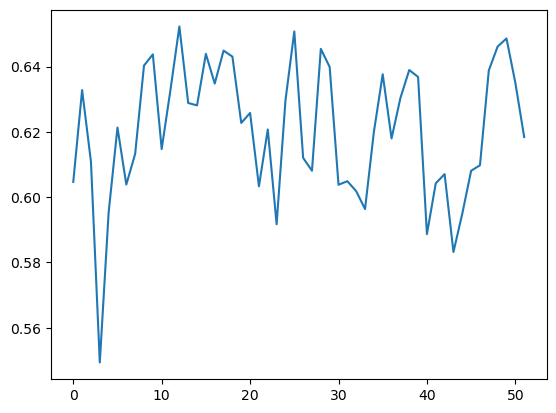

In [138]:
#plt.plot(plaq_measurements)
plt.plot(plaq_measurements_gf)

In [111]:
for i in range(100):
    U = ft0(U)
    print(trace_U(U))

[-0.06006467]
[-0.10002885]
[-0.13538488]
[-0.16607211]
[-0.19229043]
[-0.21443524]
[-0.23301458]
[-0.24857093]
[-0.26162277]
[-0.27263054]
[-0.28198318]
[-0.28999845]
[-0.29693056]
[-0.30298052]
[-0.30830653]
[-0.3130332]
[-0.3172591]
[-0.32106273]
[-0.32450711]
[-0.32764333]
[-0.33051315]
[-0.33315105]
[-0.33558573]
[-0.33784131]
[-0.33993821]
[-0.34189386]
[-0.34372324]
[-0.34543936]
[-0.34705352]
[-0.34857567]
[-0.35001458]
[-0.35137803]
[-0.35267298]
[-0.35390563]
[-0.35508158]
[-0.35620586]
[-0.35728303]
[-0.35831722]
[-0.3593122]
[-0.36027137]
[-0.36119786]
[-0.3620945]
[-0.36296392]
[-0.36380849]
[-0.3646304]
[-0.36543165]
[-0.36621411]
[-0.36697946]
[-0.36772929]
[-0.36846504]
[-0.36918807]
[-0.36989961]
[-0.37060084]
[-0.37129285]
[-0.37197663]
[-0.37265315]
[-0.3733233]
[-0.37398791]
[-0.37464779]
[-0.37530366]
[-0.37595625]
[-0.37660621]
[-0.37725417]
[-0.37790071]
[-0.37854637]
[-0.37919166]
[-0.37983702]
[-0.38048287]
[-0.38112955]
[-0.38177738]
[-0.38242659]
[-0.38307735

In [ ]:
for i in range(10):
    i = random.randint(0, 1)
    print(i)